In [1]:
import optuna
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
from optuna.samplers import GridSampler,RandomSampler

In [2]:
df = pd.read_csv("one_hand_data.csv")

In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,label
0,0.499906,0.744863,-3.627732e-07,0.577877,0.715979,-0.026104,0.647876,0.628825,-0.032937,0.631898,...,0.483146,0.458679,-0.031348,0.490664,0.519978,-0.014028,0.482650,0.540221,0.003154,Start
1,0.500604,0.744754,-3.385527e-07,0.578189,0.714752,-0.027308,0.648732,0.625959,-0.034383,0.632711,...,0.483354,0.459536,-0.030126,0.490978,0.520967,-0.013127,0.482670,0.540963,0.004052,Start
2,0.499253,0.744798,-3.591698e-07,0.576410,0.715607,-0.026986,0.647985,0.628086,-0.034177,0.633615,...,0.482863,0.459103,-0.031465,0.490899,0.520326,-0.014265,0.482994,0.540170,0.002896,Start
3,0.499893,0.742758,-3.511142e-07,0.578850,0.714535,-0.026490,0.649312,0.627751,-0.033521,0.632899,...,0.483775,0.458284,-0.031481,0.491277,0.520029,-0.014389,0.483177,0.540461,0.002805,Start
4,0.500495,0.743257,-3.536349e-07,0.579902,0.715634,-0.025760,0.649092,0.627919,-0.032398,0.632631,...,0.484482,0.458969,-0.033108,0.491806,0.521371,-0.016038,0.482613,0.541819,0.001155,Start
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57995,0.357419,0.930349,5.418301e-08,0.408664,0.886600,-0.025748,0.452132,0.795038,-0.041652,0.429595,...,0.316419,0.731811,-0.077533,0.336845,0.781914,-0.067259,0.333466,0.804957,-0.052979,Z
57996,0.355599,0.931010,3.929772e-08,0.406506,0.886801,-0.025504,0.449532,0.794187,-0.041115,0.426699,...,0.313811,0.731389,-0.077342,0.334497,0.782837,-0.066566,0.332056,0.806385,-0.051718,Z
57997,0.353567,0.930168,5.200473e-08,0.404090,0.885576,-0.026323,0.447108,0.793537,-0.042574,0.423463,...,0.311697,0.730977,-0.077513,0.332026,0.781407,-0.067374,0.329205,0.804234,-0.052946,Z
57998,0.352029,0.928345,5.206770e-08,0.402607,0.883359,-0.026116,0.445236,0.791624,-0.041950,0.421394,...,0.308719,0.730835,-0.076138,0.329391,0.781546,-0.065800,0.327558,0.804247,-0.051177,Z


In [4]:
fv = df.iloc[:,:-1]

In [5]:
cv = df.iloc[:,-1]

In [6]:
final_scaling = []
for i in fv.values:
    md = i.reshape(21,3)
    center = md - md[0]
    distance = np.linalg.norm(md[0]-md[12])
    fpd = center/(distance+1e-6)
    final_scaling.append(fpd.flatten())

In [7]:
fv = final_scaling

In [13]:
len(final_scaling)

58000

In [8]:
x_train, x_test, y_train, y_test = train_test_split(fv,cv,test_size=0.2,stratify=cv)

In [9]:
def objective(trial):
    d1 = trial.suggest_int("d1", 4, 11)
    max_sample = trial.suggest_categorical("max_sample", [0.7, 0.8, 0.9])
    n = trial.suggest_int("n", 4, 20)
    model = RandomForestClassifier(n_estimators=n, max_depth=d1, max_samples=max_sample)
    
    values = cross_validate(
        estimator=model,
        X=x_train,
        y=y_train,
        scoring="accuracy",
        cv=4,
        return_train_score=True,
        n_jobs=-1
    )
    
    train_ac = values["train_score"].mean()
    test_ac = values["test_score"].mean()
    trial.set_user_attr("train_ac", train_ac)
    
    return test_ac

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
study.optimize(objective, n_trials=100)  

[I 2025-07-25 18:18:45,243] A new study created in memory with name: no-name-90a7c192-fad8-4222-b899-4faaf224a7dd
[I 2025-07-25 18:19:12,318] Trial 0 finished with value: 0.8770258620689655 and parameters: {'d1': 4, 'max_sample': 0.7, 'n': 16}. Best is trial 0 with value: 0.8770258620689655.
[I 2025-07-25 18:19:38,623] Trial 1 finished with value: 0.9030387931034483 and parameters: {'d1': 4, 'max_sample': 0.7, 'n': 17}. Best is trial 1 with value: 0.9030387931034483.
[I 2025-07-25 18:19:58,840] Trial 2 finished with value: 0.9999137931034483 and parameters: {'d1': 11, 'max_sample': 0.9, 'n': 8}. Best is trial 2 with value: 0.9999137931034483.
[I 2025-07-25 18:20:19,218] Trial 3 finished with value: 0.7637931034482759 and parameters: {'d1': 4, 'max_sample': 0.9, 'n': 12}. Best is trial 2 with value: 0.9999137931034483.
[I 2025-07-25 18:20:41,635] Trial 4 finished with value: 0.9998922413793103 and parameters: {'d1': 10, 'max_sample': 0.9, 'n': 12}. Best is trial 2 with value: 0.99991379

In [10]:
study.best_value

0.9999137931034483

In [11]:
study.best_params

{'d1': 11, 'max_sample': 0.9, 'n': 8}

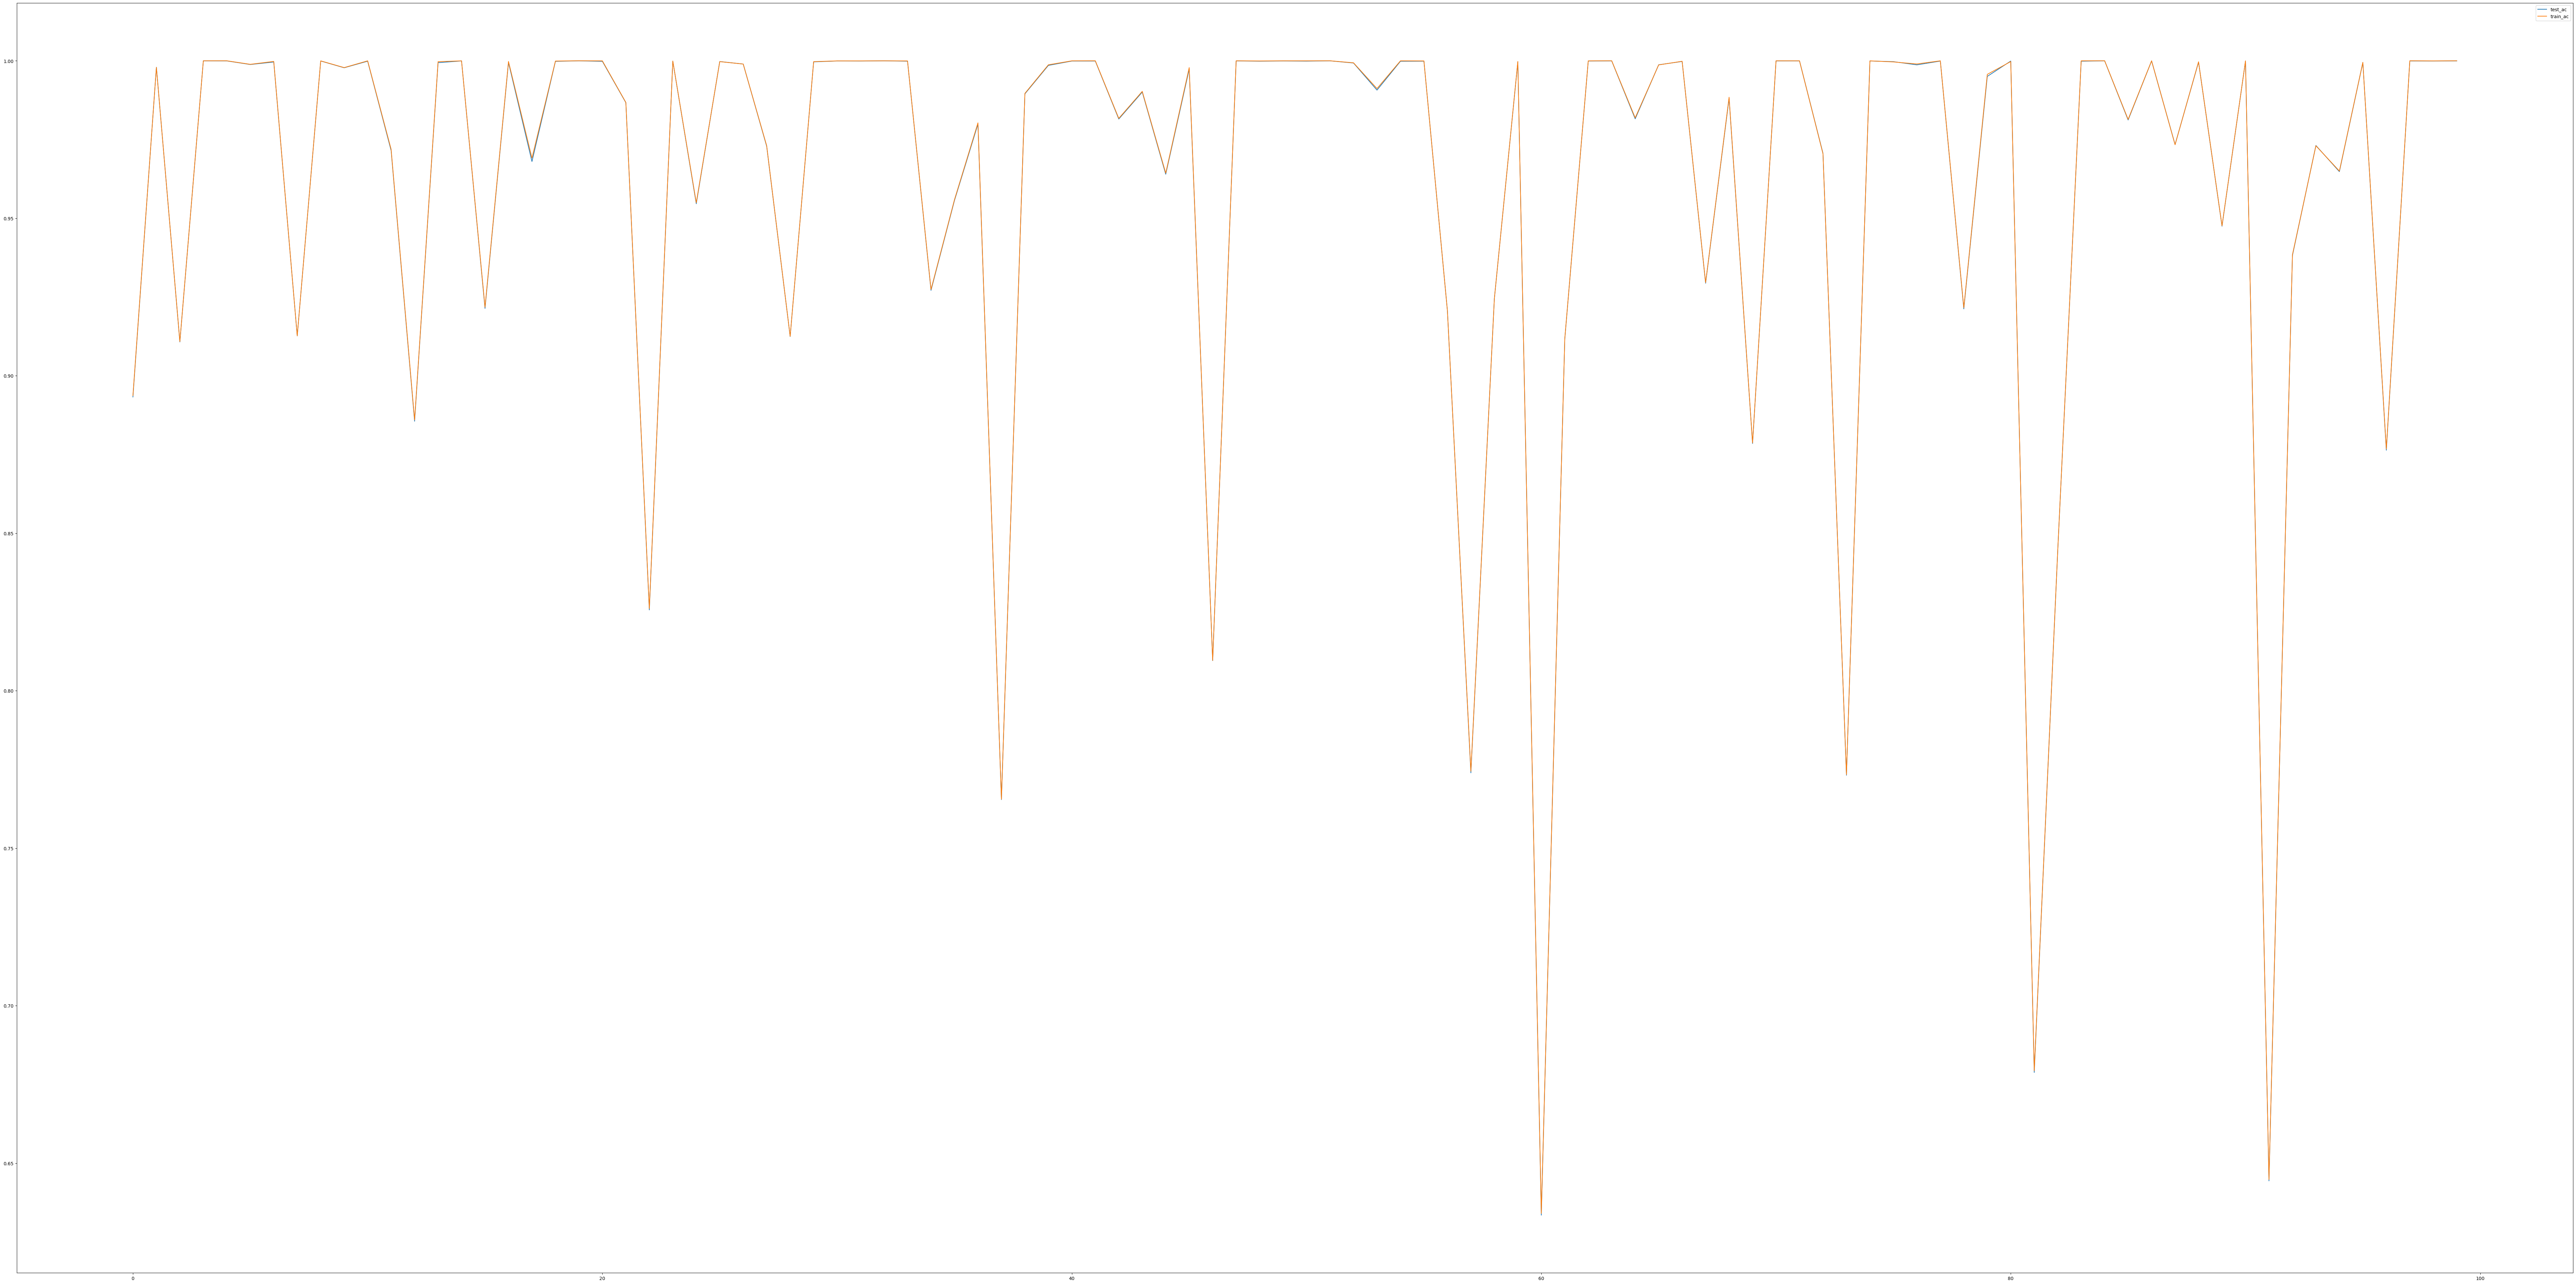

In [20]:
plt.figure(figsize=(100,50))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="test_ac")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_train_ac"],label="train_ac")
plt.legend()
plt.show()

In [12]:
rfc = RandomForestClassifier(n_estimators=8,max_depth=11,max_samples=0.9)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

1.0

In [23]:
import pickle

In [26]:
col = pd.DataFrame(x_train)

In [28]:
with open("preprocess_randomforest_hands.plk", "wb") as f:
    pickle.dump((model,col.columns), f)

In [29]:
model

RandomForestClassifier(max_depth=11, max_samples=0.9, n_estimators=15)

In [ ]:
with open("preprocess_randomforest_hands.plk", "rb") as f:
    rf,f = pickle.load(f)

In [5]:
import cv2
import time
import pickle
import pandas as pd
import mediapipe as mp


hd = mp.solutions.hands
model1 = hd.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)

with open("handModelSurya.plk", "rb") as f:
    rfc= pickle.load(f)

vid = cv2.VideoCapture(3)

st = ''

last_prediction_time = 0
prediction_delay = 4 

while True:
    s, f = vid.read()
    
    if not s:
        break
    f = cv2.flip(f,1)
    rgb = f[:, :, ::-1] 
    result = model1.process(rgb)

    if result.multi_hand_landmarks:
        row = []
        for i in result.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(f, i, hd.HAND_CONNECTIONS)
            for j in i.landmark:
                row.extend([j.x, j.y, j.z])
        
        if len(row) == 63:
            pre1 = []
            md = np.array(row).reshape(21,3)
            center = md - md[0]
            distance = np.linalg.norm(md[0]-md[12])
            fpd = center/(distance+1e-6)
            pre1.append(fpd.flatten())
            
            current_time = time.time()
            if current_time - last_prediction_time >= prediction_delay:
                pre = rfc.predict(pre1)[0]
                if pre == "Backspace":
                    st = st[:-1]
                else:
                    st = st + pre

                last_prediction_time = current_time 
                cv2.putText(f, f"Predicted Char: {pre}", (50, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

    cv2.putText(f, f"Typed Text: {st}", (50, 120), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("Koushik", f)

    if cv2.waitKey(1) & 0xFF == 27: 
        break

vid.release()
cv2.destroyAllWindows()

In [2]:
import numpy as np

In [6]:
fv

NameError: name 'fv' is not defined